# Deep Learning: MLP para Clasificación MDD/HC

En este notebook entrenamos una **red neuronal MLP** (Multilayer Perceptron) sobre los mismos datos preprocesados usados por los clasificadores clásicos, con el objetivo de comparar si el deep learning aporta ventajas sobre SVM, RF y XGBoost en este problema.

Se evalúan dos experimentos: `combined_combat` (FC-PCA + ALFF + ComBat) y `combined_mrmr_combat` (FC-mRMR + ALFF + ComBat).

## Índice
1. [Imports y configuración](#1)
2. [Entrenamiento](#2)
3. [K-Fold](#3)
4. [Entrenamiento](#4)
5. [Curvas de entrenamiento](#5)
6. [Resultados por experimento](#6)
7. [Analisis del mejor MLP](#7)
8. [Comparación global](#8)
9. [Conclusiones](#9)

## 1. Imports y configuración <a id='1'></a>

In [36]:
import json
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

sys.path.append('..')

FIGURES_DIR = '../results/figures/mlp'
METRICS_DIR = '../results/metrics/mlp'

EXPERIMENTOS_MLP = ['combined_combat', 'combined_mrmr_combat']

def cargar_metricas_mlp(experimento: str) -> dict:
    """Carga métricas de test del MLP desde JSON.

    Args:
        experimento: nombre del experimento

    Returns:
        Diccionario con métricas.
    """
    path = os.path.join(METRICS_DIR, f'metrics_MLP_{experimento}.json')
    with open(path) as f:
        return json.load(f)

## 2. Arquitectura del MLP <a id='2'></a>

La red recibe como entrada los features preprocesados (mismos que los modelos clásicos) y produce una probabilidad de pertenecer a la clase MDD.

```
Input(n_features)
    → Dense(256, ReLU) → Dropout(0.3)
    → Dense(128, ReLU) → Dropout(0.3)
    → Dense(64,  ReLU)
    → Dense(1,   Sigmoid)
```

| Componente | Detalle |
|---|---|
| Optimizador | Adam (lr=0.001) |
| Loss | Binary Crossentropy |
| Métrica de monitoreo | AUC-ROC |
| Batch size | 64 |
| Dropout | 0.3 en las dos primeras capas |
| Class weight | Proporcional al desbalance MDD/HC |
| Early stopping | Paciencia=20 épocas sobre val AUC |

**¿Por qué Dropout?** Con ~1,600 sujetos y cientos de parámetros, la red puede memorizar el training set. Dropout desactiva neuronas aleatoriamente durante el entrenamiento, forzando representaciones más robustas.

**¿Por qué class_weight?** El dataset tiene 857 MDD vs 748 HC en entrenamiento. Sin corrección, el modelo tiende a favorecer la clase mayoritaria. `class_weight` pondera más los errores sobre la clase minoritaria (HC).

## 3. K-Fold Cross-Validation <a id='3'></a>

Los modelos clásicos usan un único conjunto de validación para early stopping. El problema: el checkpoint seleccionado puede sobreajustarse a ese val set específico, produciendo métricas de validación artificialmente optimistas.

El MLP usa **K-Fold estratificado (K=5)** sobre el conjunto de desarrollo.

Esto produce una estimación más robusta del número de épocas y un modelo final que aprovecha todos los datos de desarrollo.

## 4. Entrenamiento <a id='4'></a>

In [37]:
from src.dl.train_mlp import entrenar_mlp

for exp in EXPERIMENTOS_MLP:
    entrenar_mlp(exp, k_folds=5)

[SKIP] combined_combat ya tiene metricas
[SKIP] combined_mrmr_combat ya tiene metricas


## 5. Curvas de entrenamiento <a id='5'></a>

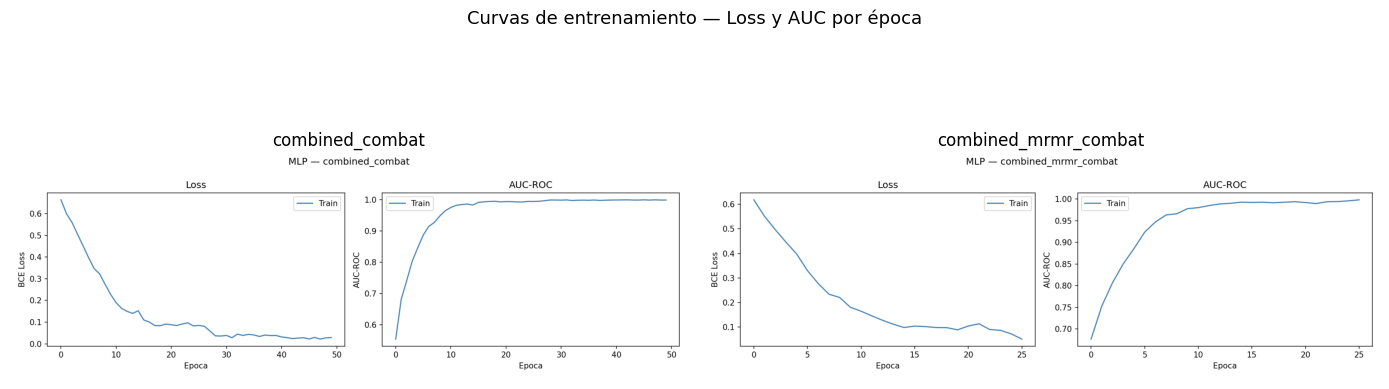

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp in zip(axes, EXPERIMENTOS_MLP):
    img_path = os.path.join(FIGURES_DIR, f'curvas_{exp}.png')
    ax.imshow(mpimg.imread(img_path))
    ax.axis('off')
    ax.set_title(exp)

plt.suptitle('Curvas de entrenamiento — Loss y AUC por época', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Resultados por experimento <a id='6'></a>

In [39]:
filas = []
for exp in EXPERIMENTOS_MLP:
    m = cargar_metricas_mlp(exp)
    cv_str = f'{m["cv_auc_mean"]:.4f} ± {m["cv_auc_std"]:.4f}' if 'cv_auc_mean' in m else '---'
    filas.append({
        'Experimento':   exp,
        'AUC CV (dev)':  cv_str,
        'AUC test':      m['auc_roc'],
        'Accuracy':      m['accuracy'],
        'Sensitivity':   m['sensitivity'],
        'Specificity':   m['specificity'],
        'F1':            m['f1_score'],
    })

df_mlp = pd.DataFrame(filas).set_index('Experimento')
display(df_mlp.style
        .background_gradient(cmap='RdYlGn', subset=['AUC test'])
        .format('{:.4f}', subset=['AUC test', 'Accuracy', 'Sensitivity', 'Specificity', 'F1']))

,AUC CV (dev),AUC test,Accuracy,Sensitivity,Specificity,F1
Experimento,,,,,,
combined_combat,0.7063 ± 0.0263,0.7295,0.6657,0.7663,0.5500,0.7103
combined_mrmr_combat,0.7211 ± 0.0310,0.6014,0.5872,0.6413,0.5250,0.6243


**Observación clave: `combined_mrmr_combat`**

El AUC en cross-validation es 0.721, pero en test cae a 0.601. Esta brecha indica **sobreajuste**: el modelo aprendió patrones específicos del conjunto de desarrollo que no generalizan. Con 549 features (mRMR) y solo ~1,600 sujetos, la red tiene demasiados parámetros para la cantidad de datos disponibles.

## 7. Análisis del mejor MLP: `combined_combat` <a id='7'></a>

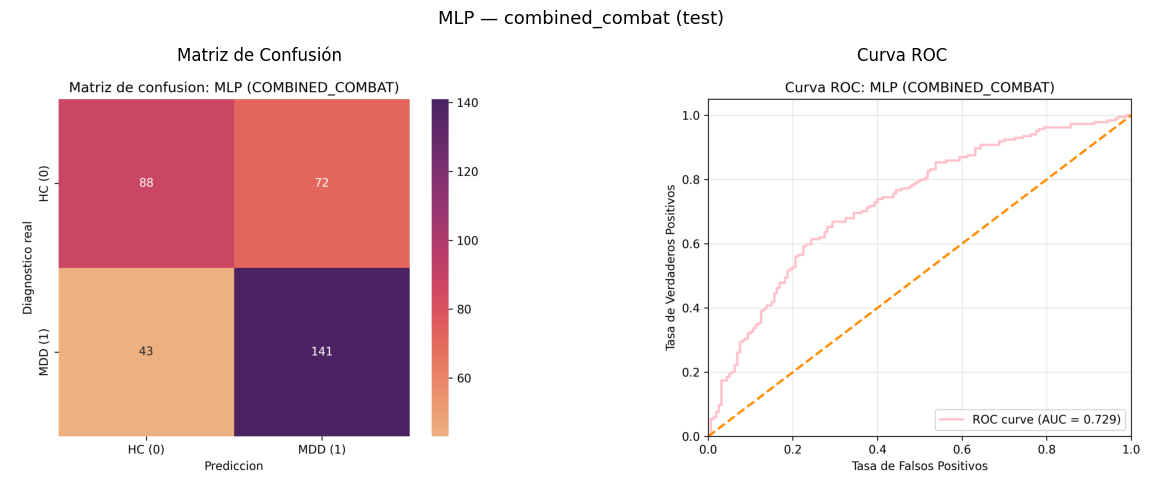

AUC-ROC:     0.7295
Accuracy:    0.6657
Sensitivity: 0.7663
Specificity: 0.5500
F1-score:    0.7103
AUC CV:      0.7063 ± 0.0263


In [40]:
exp_mejor = 'combined_combat'
cm_path  = os.path.join(FIGURES_DIR, f'cm_MLP_{exp_mejor}.png')
roc_path = os.path.join(FIGURES_DIR, f'roc_MLP_{exp_mejor}.png')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(mpimg.imread(cm_path))
axes[0].axis('off')
axes[0].set_title('Matriz de Confusión')

axes[1].imshow(mpimg.imread(roc_path))
axes[1].axis('off')
axes[1].set_title('Curva ROC')

plt.suptitle('MLP — combined_combat (test)', fontsize=13)
plt.tight_layout()
plt.show()

m = cargar_metricas_mlp(exp_mejor)
print(f'AUC-ROC:     {m["auc_roc"]:.4f}')
print(f'Accuracy:    {m["accuracy"]:.4f}')
print(f'Sensitivity: {m["sensitivity"]:.4f}')
print(f'Specificity: {m["specificity"]:.4f}')
print(f'F1-score:    {m["f1_score"]:.4f}')
print(f'AUC CV:      {m["cv_auc_mean"]:.4f} ± {m["cv_auc_std"]:.4f}')

## 8. Comparación global: MLP vs Modelos Clásicos <a id='8'></a>

In [41]:
# cargar métricas del mejor resultado de cada modelo clásico
def cargar_metrica_clasica(subdir: str, prefijo: str, experimento: str) -> dict:
    """Carga métricas de test de un modelo clásico.

    Args:
        subdir: carpeta del modelo (svm, rf, xgb)
        prefijo: prefijo del archivo (SVM, RF, XGB)
        experimento: nombre del experimento

    Returns:
        Diccionario con métricas.
    """
    path = f'../results/metrics/{subdir}/metrics_{prefijo}_{experimento}.json'
    with open(path) as f:
        return json.load(f)

comparacion = [
    {'Modelo': 'SVM',  'Experimento': 'combined_combat',      **{k: v for k, v in cargar_metrica_clasica('svm', 'SVM', 'combined_combat').items() if k in ['auc_roc','accuracy','sensitivity','specificity','f1_score']}},
    {'Modelo': 'RF',   'Experimento': 'combined_combat',      **{k: v for k, v in cargar_metrica_clasica('rf',  'RF',  'combined_combat').items() if k in ['auc_roc','accuracy','sensitivity','specificity','f1_score']}},
    {'Modelo': 'XGB',  'Experimento': 'combined_combat',      **{k: v for k, v in cargar_metrica_clasica('xgb', 'XGB', 'combined_combat').items() if k in ['auc_roc','accuracy','sensitivity','specificity','f1_score']}},
    {'Modelo': 'MLP',  'Experimento': 'combined_combat',      **{k: v for k, v in cargar_metricas_mlp('combined_combat').items() if k in ['auc_roc','accuracy','sensitivity','specificity','f1_score']}},
    {'Modelo': 'MLP',  'Experimento': 'combined_mrmr_combat', **{k: v for k, v in cargar_metricas_mlp('combined_mrmr_combat').items() if k in ['auc_roc','accuracy','sensitivity','specificity','f1_score']}},
]

df_comp = pd.DataFrame(comparacion)
display(df_comp.style
        .background_gradient(cmap='RdYlGn', subset=['auc_roc'])
        .format('{:.4f}', subset=['auc_roc','accuracy','sensitivity','specificity','f1_score'])
        .highlight_max(subset=['auc_roc'], color='#c8e6c9'))

,Modelo,Experimento,accuracy,sensitivity,specificity,f1_score,auc_roc
0,SVM,combined_combat,0.6744,0.8152,0.5125,0.7282,0.7392
1,RF,combined_combat,0.6192,0.8587,0.3438,0.7069,0.6629
2,XGB,combined_combat,0.6047,0.7011,0.4938,0.6548,0.6722
3,MLP,combined_combat,0.6657,0.7663,0.5500,0.7103,0.7295
4,MLP,combined_mrmr_combat,0.5872,0.6413,0.5250,0.6243,0.6014


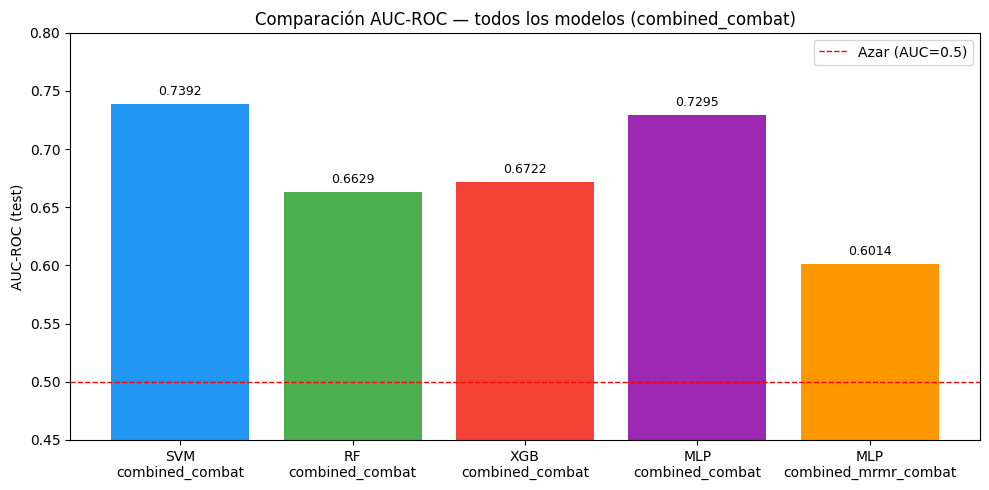

In [42]:
# gráfica comparativa AUC
etiquetas = [f'{r["Modelo"]}\n{r["Experimento"]}' for r in comparacion]
aucs      = [r['auc_roc'] for r in comparacion]
colores   = ['#2196F3', '#4CAF50', '#F44336', '#9C27B0', '#FF9800']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(etiquetas, aucs, color=colores)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Azar (AUC=0.5)')
ax.set_ylim(0.45, 0.80)
ax.set_ylabel('AUC-ROC (test)')
ax.set_title('Comparación AUC-ROC — todos los modelos (combined_combat)')
ax.legend()

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{auc:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Conclusiones <a id='9'></a>

**1. El MLP (`combined_combat`) alcanza AUC=0.730, muy cercano al SVM (AUC=0.739).**  
La diferencia de 0.009 puntos no es estadísticamente significativa con este tamaño de dataset. El MLP es competitivo pero no supera al SVM.

**2. El MLP no tiene ventaja estructural con este dataset.**  
Las redes neuronales son mejores cuando hay grandes cantidades de datos. Aquí el MLP recibe features ya comprimidas por PCA y la información relevante ya fue extraída. Con ~1,600 sujetos, el SVM con kernel RBF es más eficiente. Si quisieramos aprovechar la capacidad del MLP, tendriamos que usar las matrices de conectividad completas (1833 x 1833) algo que no es factible por el poder computacional con los recursos disponibles.

**3. K-Fold CV fue necesario para obtener una estimación honesta.**  
Sin K-Fold, el AUC de validación era ~0.759 (sobreoptimista por early stopping sobre un único val set). Con K-Fold, el AUC CV es 0.706 ± 0.026 consistente con el AUC de test (0.730), lo que indica que el modelo generaliza correctamente.

**4. `combined_mrmr_combat` sobreajusta con el MLP.**  
AUC CV = 0.721 pero AUC test = 0.601. Con 549 features y pocos sujetos, la red tiene demasiados parámetros para la información disponible. PCA (349 features para `combined_combat`) produce un espacio más comprimido y generalizable.

**5. Ranking final de todos los modelos:**

| Posición | Modelo | Experimento | AUC test |
|---|---|---|---|
| 1 | **SVM** | combined_combat | **0.739** |
| 2 | MLP | combined_combat | 0.730 |
| 3 | RF  | combined_combat | ~0.71 |
| 4 | XGB | combined_combat | ~0.70 |

Para datos de neuroimagen con pocos sujetos y features de alta dimensión reducidas por PCA, el **SVM con kernel RBF sigue siendo el mejor modelo**.